IPL 2022 Capstone Project
The Indian Premier League (IPL) is a professional T20 cricket league in India, featuring franchises representing cities. This project explores IPL 2022 match-level data to derive meaningful insights and understand match outcomes, player performances, and team dynamics.

These are some of the important columns that we'll focus on for meaningful insights in this project.

column names: Variable Type

date : string
venue : string
stage : string
team1 : string
team2 : string
toss_winner : string
toss_decision : string
first_ings_score : integer
second_ings_score : integer
match_winner : string
won_by : string
margin : integer
player_of_the_match : string
top_scorer : string
highscore : integer
best_bowling : string
best_bowling_fgure : string
gure : string

Loading the Libraries and Dataset

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
df=pd.read_csv('IPL.csv')
df.head()

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,second_ings_score,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure
0,1,"March 26,2022","Wankhede Stadium, Mumbai",Chennai,Kolkata,Group,Kolkata,Field,131,5,133,4,Kolkata,Wickets,6,Umesh Yadav,MS Dhoni,50,Dwayne Bravo,3--20
1,2,"March 27,2022","Brabourne Stadium, Mumbai",Delhi,Mumbai,Group,Delhi,Field,177,5,179,6,Delhi,Wickets,4,Kuldeep Yadav,Ishan Kishan,81,Kuldeep Yadav,3--18
2,3,"March 27,2022","Dr DY Patil Sports Academy, Mumbai",Banglore,Punjab,Group,Punjab,Field,205,2,208,5,Punjab,Wickets,5,Odean Smith,Faf du Plessis,88,Mohammed Siraj,2--59
3,4,"March 28,2022","Wankhede Stadium, Mumbai",Gujarat,Lucknow,Group,Gujarat,Field,158,6,161,5,Gujarat,Wickets,5,Mohammed Shami,Deepak Hooda,55,Mohammed Shami,3--25
4,5,"March 29,2022","Maharashtra Cricket Association Stadium,Pune",Hyderabad,Rajasthan,Group,Hyderabad,Field,210,6,149,7,Rajasthan,Runs,61,Sanju Samson,Aiden Markram,57,Yuzvendra Chahal,3--22


BASIC INFORMATION

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74 entries, 0 to 73
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   match_id             74 non-null     int64 
 1   date                 74 non-null     object
 2   venue                74 non-null     object
 3   team1                74 non-null     object
 4   team2                74 non-null     object
 5   stage                74 non-null     object
 6   toss_winner          74 non-null     object
 7   toss_decision        74 non-null     object
 8   first_ings_score     74 non-null     int64 
 9   first_ings_wkts      74 non-null     int64 
 10  second_ings_score    74 non-null     int64 
 11  second_ings_wkts     74 non-null     int64 
 12  match_winner         74 non-null     object
 13  won_by               74 non-null     object
 14  margin               74 non-null     int64 
 15  player_of_the_match  74 non-null     object
 16  top_scorer

check rows and columns

In [4]:
print(f"Number of rows = {df.shape[0]} amd number of columns = {df.shape[1]}")


Number of rows = 74 amd number of columns = 20


how many colums have  null values in total

In [6]:
df.isnull().sum()

match_id               0
date                   0
venue                  0
team1                  0
team2                  0
stage                  0
toss_winner            0
toss_decision          0
first_ings_score       0
first_ings_wkts        0
second_ings_score      0
second_ings_wkts       0
match_winner           0
won_by                 0
margin                 0
player_of_the_match    0
top_scorer             0
highscore              0
best_bowling           0
best_bowling_figure    0
dtype: int64

which team won the most matches

In [21]:
match_wins=df['match_winner'].value_counts()
match_wins

match_winner
Gujarat      12
Rajasthan    10
Banglore      9
Lucknow       9
Punjab        7
Delhi         7
Kolkata       6
Hyderabad     6
Chennai       4
Mumbai        4
Name: count, dtype: int64

Text(0.5, 1.0, 'visual analysis of matches won by each team')

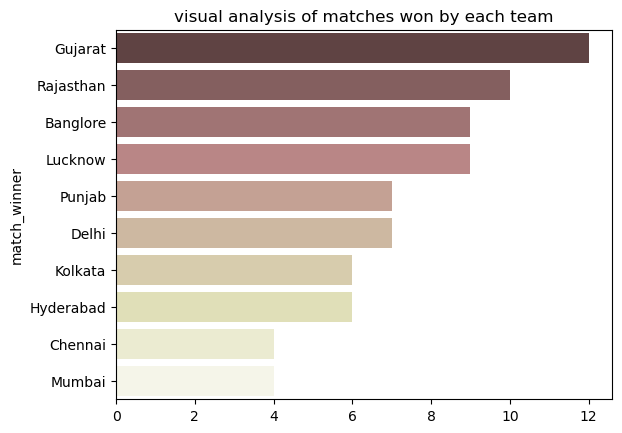

In [22]:
sns.barplot(x=match_wins.values,y=match_wins.index,palette='pink')
plt.title('visual analysis of matches won by each team')

toss decision trend

Text(0.5, 1.0, 'visual analysis of toss decision')

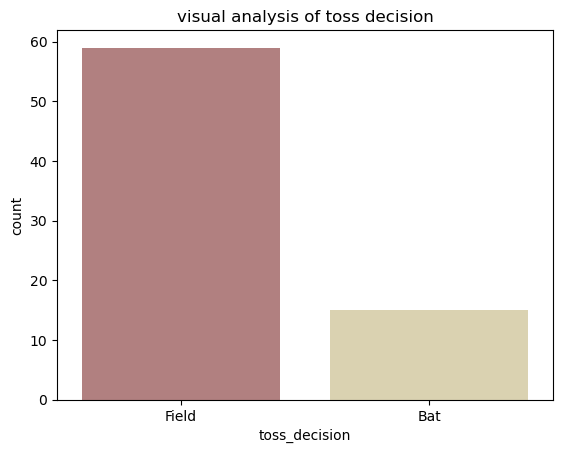

In [5]:
sns.countplot(x="toss_decision",data=df,palette='pink')
plt.title('visual analysis of toss decision')

toss winner vs match winner

In [8]:
count=df[df['toss_winner']==df['match_winner']]['match_id'].count()
percentage=(count*100)/df.shape[0]
percentage.round(2)

np.float64(48.65)

runs vs wickets

Text(0.5, 1.0, 'Visual analysis of how teams won the match')

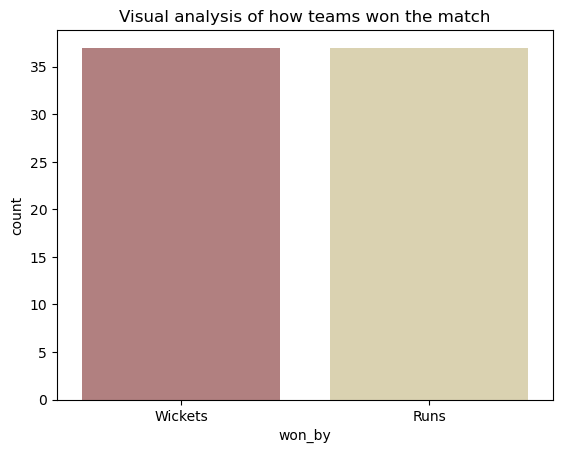

In [13]:
sns.countplot(x=df['won_by'],palette='pink')
plt.title('Visual analysis of how teams won the match')

key player performances

1. most player of the match award

Text(0.5, 1.0, 'visual analysis of players who won the most player of the match awards')

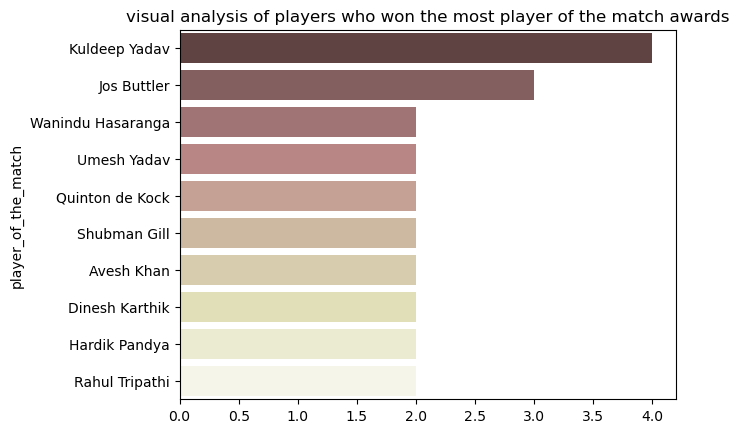

In [19]:
count=df['player_of_the_match'].value_counts().head(10)#takes top 10
sns.barplot(x=count.values,y=count.index,palette='pink')
plt.title('visual analysis of players who won the most player of the match awards')

2 top scorers

In [8]:
high=df.groupby('top_scorer')['highscore'].sum().sort_values(ascending=False).head(2)
high

top_scorer
Jos Buttler        651
Quinton de Kock    377
Name: highscore, dtype: int64

<Axes: xlabel='top_scorer'>

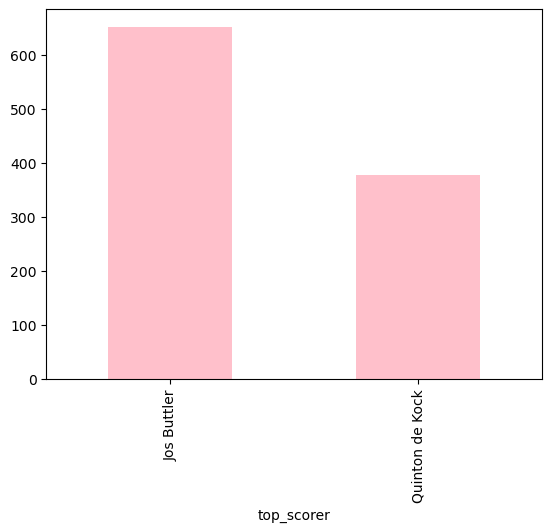

In [9]:
high.plot(kind='bar',color='pink')

10 best bowling figures

<Axes: xlabel='best_bowling'>

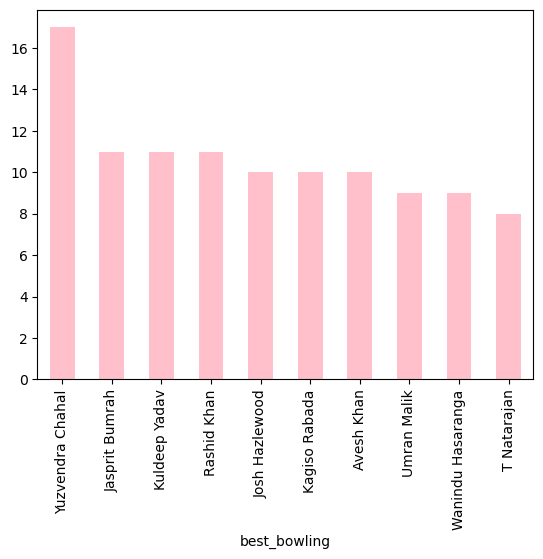

In [5]:

df['highest_wickets']=df['best_bowling_figure'].apply(lambda x: x.split('--')[0])
df['highest_wickets']=df['highest_wickets'].astype(int)
top_bowlers=df.groupby('best_bowling')['highest_wickets'].sum().sort_values(ascending=False).head(10)
top_bowlers.plot(kind='bar',color='pink')

venue analysis-most match played by venue

<Axes: xlabel='venue'>

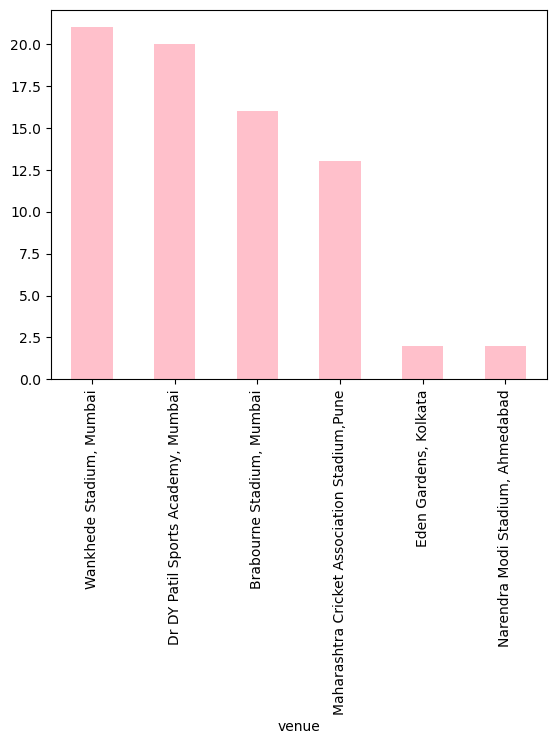

In [4]:
venue_count=df['venue'].value_counts()
venue_count.plot(kind='bar',color='pink')

In [13]:
#who won the highest margin by runs?
df[df['won_by']=='Runs'].sort_values(by='margin',ascending=False).head(1)[['match_winner','margin']]

,match_winner,margin
54,Chennai,91


In [16]:
#which player has the highest individual score?
df[df['highscore']==df['highscore'].max()][['top_scorer','highscore']]

,top_scorer,highscore
65,Quinton de Kock,140


In [ ]:
#which bowler had the best bowling figure?
df[df['highest_wickets']==df['highest_wickets'].max()][['best_bowling','best_bowling_figure']]

,best_bowling,best_bowling_figure
29,Yuzvendra Chahal,5--40
39,Umran Malik,5--25
53,Wanindu Hasaranga,5--18
55,Jasprit Bumrah,5--10
